[Stage] s_co=2.5: 전체 map 훑어보기 (W, C, coeffs, sparsity) 시작…
[Done]  s_co=2.5: 전체 map 훑어보기 완료
[Progress] s_co=2.5: 출력 step 0/2999 (t=0.000 μs) 완료
[Progress] s_co=2.5: 출력 step 10/2999 (t=0.200 μs) 완료
[Progress] s_co=2.5: 출력 step 20/2999 (t=0.400 μs) 완료
[Progress] s_co=2.5: 출력 step 30/2999 (t=0.600 μs) 완료
[Progress] s_co=2.5: 출력 step 40/2999 (t=0.800 μs) 완료
[Progress] s_co=2.5: 출력 step 50/2999 (t=1.000 μs) 완료
[Progress] s_co=2.5: 출력 step 60/2999 (t=1.200 μs) 완료
[Progress] s_co=2.5: 출력 step 70/2999 (t=1.400 μs) 완료
[Progress] s_co=2.5: 출력 step 80/2999 (t=1.601 μs) 완료
[Progress] s_co=2.5: 출력 step 90/2999 (t=1.801 μs) 완료
[Progress] s_co=2.5: 출력 step 100/2999 (t=2.001 μs) 완료
[Progress] s_co=2.5: 출력 step 110/2999 (t=2.201 μs) 완료
[Progress] s_co=2.5: 출력 step 120/2999 (t=2.401 μs) 완료
[Progress] s_co=2.5: 출력 step 130/2999 (t=2.601 μs) 완료
[Progress] s_co=2.5: 출력 step 140/2999 (t=2.801 μs) 완료
[Progress] s_co=2.5: 출력 step 150/2999 (t=3.001 μs) 완료
[Progress] s_co=2.5: 출력 step 160/2999 (t=3.201 μs) 완료
[

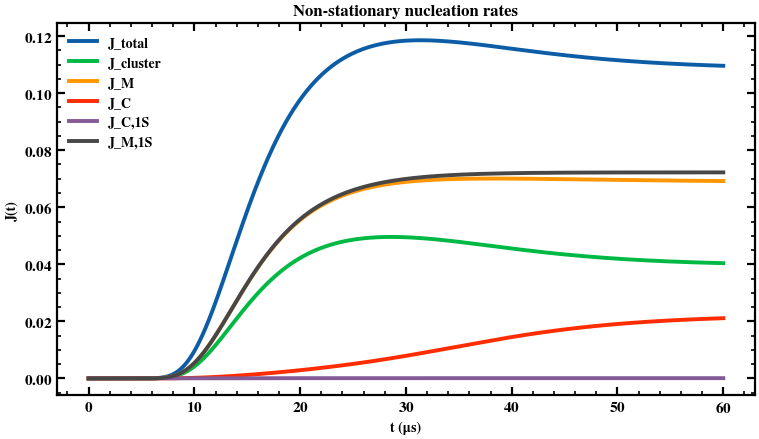

In [1]:
# ============================================================
# Two-Step Nucleation (2S) — BDF solver with sparse Jacobian
# - Memory-safe: triangular indexing + jac_sparsity
# - Time-step: BDF (adaptive) + max_step control
# - Progress prints: stage marks + every 10 output steps
# - ONLY s_co = 2.5
# - BOLD plot styling
# ============================================================

import numpy as np
import scipy.sparse as sp
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# ------------------------
# 0) STYLE (BOLD)
# ------------------------
try:
    import scienceplots
    plt.style.use(["science", "no-latex"])
except Exception:
    plt.style.use("default")

plt.rcParams.update({
    "font.weight": "bold",
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "axes.linewidth": 1.6,
    "xtick.major.width": 1.6,
    "ytick.major.width": 1.6,
    "xtick.minor.width": 1.2,
    "ytick.minor.width": 1.2,
    "lines.linewidth": 2.4,
})

# ------------------------
# 1) PARAMETERS
# ------------------------
T = 220.0
SCO_LIST = [2.5]          # <- only s_co = 2.5
s_cm = 0.5
gamma_co, gamma_cm, gamma_mo = 15.4, 2.6, 12.8  # gamma_co = gamma_cm + gamma_mo
f0 = 1.0e5
g0 = 2.0e7
Q  = 0.5
C1_base = 1.6e21  # C1 = C1_base * exp(s_co)
M = 240

# runtime window & sampling
t_max  = 60e-6               # 60 microseconds
N_eval = 3000                # 출력 샘플 개수
t_eval = np.linspace(0.0, t_max, N_eval)
x_eval = f0 * t_eval         # solver works in x = f0 t
max_step = 1e-7              # sec
max_dx   = f0 * max_step     # x-domain step ceiling

# ------------------------
# 2) UTILS: triangular indexing (1 <= n <= i <= M-1)
# ------------------------
def tri_index_maps(M):
    pair2idx = {}
    idx2pair = []
    k = 0
    for i in range(1, M):
        for n in range(1, i + 1):
            pair2idx[(i, n)] = k
            idx2pair.append((i, n))
            k += 1
    return pair2idx, np.array(idx2pair, dtype=int)

PAIR2IDX, IDX2PAIR = tri_index_maps(M)
Ntri = len(IDX2PAIR)

# ------------------------
# 3) Work of formation, equilibrium C, critical sizes
# ------------------------
def w_mo(i, s_mo): return -s_mo * i + gamma_mo * i**(2/3)
def w_cm(n):       return -s_cm * n + gamma_cm * n**(2/3)

def w_total_ij(i, n, s_co):
    s_mo = s_co - s_cm
    return w_mo(i, s_mo) + w_cm(n)

def make_wC(s_co):
    C1 = C1_base * np.exp(s_co)
    W = np.empty(Ntri, dtype=float)
    for k, (i, n) in enumerate(IDX2PAIR):
        W[k] = w_total_ij(i, n, s_co)
    w11 = w_total_ij(1, 1, s_co)
    C = C1 * np.exp(w11 - W)
    return W, C

def crit_sizes(s_co):
    s_mo = s_co - s_cm
    i_star   = (2*gamma_mo / (3*s_mo))**3
    n_star   = (2*gamma_cm / (3*s_cm))**3
    ico_star = (2*gamma_co / (3*s_co))**3
    return int(np.ceil(i_star)), int(np.ceil(n_star)), int(np.ceil(ico_star))

# ------------------------
# 4) Attachment frequencies (as specified)
# ------------------------
def f_in_val(i, s_co): return (1.0 - Q) * f0 * np.exp(s_co) * (i**(2/3))
def g_in_val(n):       return g0 * np.exp(s_cm) * (n**(2/3))
def k_ii_val(i, s_co): return Q * f0 * np.exp(s_co) * (i**(2/3))

def build_coeffs(W, s_co):
    a = np.zeros(Ntri); b = np.zeros(Ntri); c = np.zeros(Ntri)
    d = np.zeros(Ntri); e = np.zeros(Ntri); h = np.zeros(Ntri)
    Wmap = {(i, n): W[PAIR2IDX[(i, n)]] for (i, n) in PAIR2IDX}

    for k, (i, n) in enumerate(IDX2PAIR):
        if n < i:
            b[k] = f_in_val(i, s_co) / f0
            d[k] = g_in_val(n)       / f0
            if i >= 2:
                a[k] = (f_in_val(i-1, s_co) / f0) * np.exp(Wmap[(i, n)] - Wmap[(i-1, n)])
            if n >= 2:
                c[k] = (g_in_val(n-1) / f0)       * np.exp(Wmap[(i, n)] - Wmap[(i, n-1)])
        else:  # n == i
            if i >= 2:
                e[k] = (k_ii_val(i-1, s_co) / f0) * np.exp(Wmap[(i, i)] - Wmap[(i-1, i-1)])
            h[k] = (k_ii_val(i, s_co) / f0)
    return a, b, c, d, e, h

# ------------------------
# 5) Sparse Jacobian pattern (neighbor stencil)
# ------------------------
def jac_sparsity_pattern(M):
    rows, cols = [], []
    def add(r, c):
        rows.append(r); cols.append(c)

    for k, (i, n) in enumerate(IDX2PAIR):
        add(k, k)
        if (i-1) >= 1 and n <= (i-1):
            add(k, PAIR2IDX[(i-1, n)])
        if (i+1) <= (M-1) and n <= (i+1):
            add(k, PAIR2IDX[(i+1, n)])
        if (n-1) >= 1:
            add(k, PAIR2IDX[(i, n-1)])
        if (n+1) <= i:
            add(k, PAIR2IDX[(i, n+1)])
        if n == i:
            if (i-1) >= 1:
                add(k, PAIR2IDX[(i-1, i-1)])
            if (i+1) <= (M-1):
                add(k, PAIR2IDX[(i+1, i+1)])

    return sp.csr_matrix(
        (np.ones(len(rows), dtype=bool), (rows, cols)),
        shape=(Ntri, Ntri)
    )

JAC_SP = jac_sparsity_pattern(M)

# ------------------------
# 6) RHS in x-domain (Eq.(6)): dF/dx = ...
# ------------------------
def dFdx(x, F_flat, a, b, c, d, e, h):
    F = F_flat
    dF = np.zeros_like(F)

    F[PAIR2IDX[(1, 1)]] = 1.0  # boundary

    for k, (i, n) in enumerate(IDX2PAIR):
        val = 0.0

        if n < i and i >= 2:
            val += a[k] * (F[PAIR2IDX[(i-1, n)]] - F[k])

        if n < i:
            Fip = F[PAIR2IDX[(i+1, n)]] if (i+1 <= M-1) else 0.0
            val -= b[k] * (F[k] - Fip)

        if n >= 2:
            val += c[k] * (F[PAIR2IDX[(i, n-1)]] - F[k])

        if n < i:
            Finp = F[PAIR2IDX[(i, n+1)]] if (n+1 <= i) else 0.0
            val -= d[k] * (F[k] - Finp)

        if n == i:
            if i >= 2:
                val += e[k] * (F[PAIR2IDX[(i-1, i-1)]] - F[k])
            Fipp = F[PAIR2IDX[(i+1, i+1)]] if (i+1 <= M-1) else 0.0
            val -= h[k] * (F[k] - Fipp)

        dF[k] = val

    return dF

# ------------------------
# 7) Fluxes I,G,K (for J(t))
# ------------------------
def fluxes_IGK(F_flat, C, s_co):
    I_map = {}; G_map = {}; K_map = {}
    F = F_flat

    for (i, n), k in PAIR2IDX.items():
        Ckn = C[k]

        if n < i:
            fval = f_in_val(i, s_co)
            Fip = F[PAIR2IDX[(i+1, n)]] if (i+1 <= M-1) else 0.0
            I_map[(i, n)] = fval * Ckn * (F[k] - Fip)

        if n < i:
            gval = g_in_val(n)
            Finp = F[PAIR2IDX[(i, n+1)]] if (n+1 <= i) else 0.0
            G_map[(i, n)] = gval * Ckn * (F[k] - Finp)

        if n == i:
            kval = k_ii_val(i, s_co)
            Fipp = F[PAIR2IDX[(i+1, i+1)]] if (i+1 <= M-1) else 0.0
            K_map[(i, i)] = kval * Ckn * (F[k] - Fipp)

    return I_map, G_map, K_map

# ------------------------
# 8) Non-stationary rates
# ------------------------
def compute_Js(F_flat, C, s_co):
    i_star, n_star, ico_star = crit_sizes(s_co)
    I_map, G_map, K_map = fluxes_IGK(F_flat, C, s_co)

    gi = lambda i, n: G_map.get((i, n), 0.0)
    ii = lambda i, n: I_map.get((i, n), 0.0)
    kk = lambda i:    K_map.get((i, i), 0.0)

    J_dcom = sum(ii(i_star, n) for n in range(1, i_star + 1))
    for i in range(i_star + 1, M):
        J_dcom += ii(i, i) - gi(i, i-1)

    J_d = ii(i_star, 1) - sum(gi(i, 1) for i in range(i_star + 1, M))
    J_com = J_dcom - J_d

    J_c = kk(ico_star)
    for i in range(ico_star + 1, M):
        J_c += gi(i, i-1) - ii(i, i)

    J_c_1S = kk(ico_star)
    J_d_1S = ii(i_star, 1)

    return {
        "J_d+com": J_dcom, "J_com": J_com, "J_d": J_d,
        "J_c": J_c, "J_c,1S": J_c_1S, "J_d,1S": J_d_1S
    }

# ------------------------
# 9) MAIN SESSION
# ------------------------
def run_session(s_co):
    print(f"[Stage] s_co={s_co}: 전체 map 훑어보기 (W, C, coeffs, sparsity) 시작…")
    W, C = make_wC(s_co)
    a, b, c, d, e, h = build_coeffs(W, s_co)
    print(f"[Done]  s_co={s_co}: 전체 map 훑어보기 완료")

    F0 = np.zeros(Ntri, dtype=float)
    F0[PAIR2IDX[(1, 1)]] = 1.0

    sol = solve_ivp(
        fun=lambda x, y: dFdx(x, y, a, b, c, d, e, h),
        t_span=(0.0, x_eval[-1]),
        y0=F0,
        method="BDF",
        t_eval=x_eval,
        jac_sparsity=JAC_SP,
        rtol=1e-6, atol=1e-9,
        max_step=max_dx
    )
    if not sol.success:
        raise RuntimeError(f"solve_ivp failed: {sol.message}")

    curves = {k: np.zeros_like(sol.t) for k in ["J_d+com", "J_com", "J_d", "J_c", "J_c,1S", "J_d,1S"]}
    for j, x in enumerate(sol.t):
        F_now = sol.y[:, j]
        Js = compute_Js(F_now, C, s_co)
        for k in curves.keys():
            curves[k][j] = Js[k]

        if j % 10 == 0:
            print(f"[Progress] s_co={s_co}: 출력 step {j}/{len(sol.t)-1} (t={x/f0*1e6:.3f} μs) 완료")

    print(f"[Done]  s_co={s_co}: 전체 계산 완료")

    label_map = {
        "J_d+com": "J_total",
        "J_com":   "J_cluster",
        "J_d":     "J_M",
        "J_c":     "J_C",
        "J_c,1S":  "J_C,1S",
        "J_d,1S":  "J_M,1S"
    }

    plt.figure(figsize=(7.8, 4.6))
    order = ["J_d+com", "J_com", "J_d", "J_c", "J_c,1S", "J_d,1S"]
    t_us = sol.t / f0 * 1e6
    for name in order:
        plt.plot(t_us, curves[name], label=label_map[name], linewidth=2.8)

    plt.xlabel("t (μs)", fontweight="bold")
    plt.ylabel("J(t)", fontweight="bold")
    plt.title("Non-stationary nucleation rates", fontweight="bold")

    ax = plt.gca()
    ax.tick_params(axis="both", which="major", width=1.6, length=6, labelsize=11)
    ax.tick_params(axis="both", which="minor", width=1.2, length=3)
    for spine in ax.spines.values():
        spine.set_linewidth(1.6)

    plt.legend(prop={"weight": "bold"})
    plt.tight_layout()
    plt.show()

# ------------------------
# 10) RUN (only s_co = 2.5)
# ------------------------
for sco in SCO_LIST:
    run_session(sco)
